## Search Engine with Tools and Agents

In [2]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

C:\Users\003X65744\AppData\Local\Temp\ipykernel_36408\4084895585.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun


In [3]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=250)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [4]:
api_wrapper = ArxivAPIWrapper(top_k_results=1, doc_content_chars_max=250)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper)
print(arxiv.name)

arxiv


In [5]:
tools = [wiki, arxiv]

In [6]:
## Custom Tools (RAG Tool)
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter


USER_AGENT environment variable not set, consider setting it to identify your requests.


In [8]:
loader = WebBaseLoader("https://en.wikipedia.org/wiki/Artificial_intelligence")
docs = loader.load()
documents = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200).split_documents(docs)
vectordb = FAISS.from_documents(documents, HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2"))
retriever = vectordb.as_retriever()
retriever 

c:\Users\003X65744\Desktop\Data Science\Chatbot\chatenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4353.44it/s]


VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x000001F66E55EE40>, search_kwargs={})

In [9]:
from langchain_classic.tools.retriever import create_retriever_tool
retriever_tool = create_retriever_tool(retriever=retriever, name="search-langsmith", description="Useful for answering questions about Artificial Intelligence by retrieving relevant information from Wikipedia.")
retriever_tool.name

'search-langsmith'

In [10]:
tools = [wiki, arxiv, retriever_tool]
tools

[WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\003X65744\\Desktop\\Data Science\\Chatbot\\chatenv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=1, lang='en', load_all_available_meta=False, doc_content_chars_max=250)),
 ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=1, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=250)),
 StructuredTool(name='search-langsmith', description='Useful for answering questions about Artificial Intelligence by retrieving relevant information from Wikipedia.', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000001F66E546610>, coroutine=<function create_retriever_tool.<locals>.afun

In [11]:
## Run all the tools with Agents and LLM Models
from dotenv import load_dotenv
load_dotenv()
import os
import huggingface_hub
huggingface_hub.api_key = os.getenv("HF_TOKEN")
groq_api_key = os.getenv("GROQ_API_KEY")
from langchain_groq import ChatGroq


llm = ChatGroq(groq_api_key=groq_api_key, model="llama-3.1-8b-instant")



In [59]:
## Prompt Template
from langsmith import Client
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
hub = Client()
prompt = hub.pull_prompt("hwchase17/openai-functions-agent", dangerously_pull_public_prompt=True)
prompt.messages

[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a helpful assistant'), additional_kwargs={}),
 MessagesPlaceholder(variable_name='chat_history', optional=True),
 HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={}),
 MessagesPlaceholder(variable_name='agent_scratchpad')]

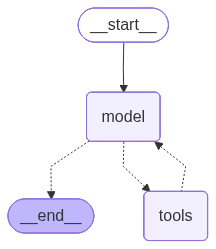

In [73]:
## Agents

from tempfile import template

from langchain.agents import create_agent
agent = create_agent(model =llm, tools = tools, system_prompt = "Tell me in detail about the question asked and use the tools to find the answer. If you don't know the answer, say you don't know. Always use the tools to find the answer if you don't know it.")
agent

In [74]:
## Agent Executor

response = agent.invoke(
    {"input": "What is Artificial Intelligence? Can you also find me a recent research paper on this topic?"})
response


{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jnvdvt4ge', 'function': {'arguments': '{"query":"question about people, places, companies, facts, historical events, or other subjects"}', 'name': 'wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 550, 'total_tokens': 579, 'completion_time': 0.05077823, 'completion_tokens_details': None, 'prompt_time': 0.037033024, 'prompt_tokens_details': None, 'queue_time': 0.051950085, 'total_time': 0.087811254}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9fed-b2b9-7eb0-b04f-ab695b4ef430-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'question about people, places, companies, facts, historical events, or other subjects'}, 'id': 'jnvdvt4ge', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadat